In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Membaca GeoJSON (jawatimur.geojson - 250 Poligon)
gdf = gpd.read_file("data/geojson/jawatimur.geojson")
print("=== TOTAL POLIGON GEODATASET MASUKAN ===")
print(gdf["Type"].value_counts())

# Memberikan ID Poligon Unik (misal: Sawah_01, Pemukiman_01, dst)
type_counts = {}
id_poligons = []
for t in gdf["Type"]:
    type_counts[t] = type_counts.get(t, 0) + 1
    id_poligons.append(f"{t.replace(' ', '_')}_{type_counts[t]:02d}")
gdf["ID_Poligon"] = id_poligons

# 2. Pembagian Stratified Split (70% Training, 30% Testing) Berdasarkan ID Poligon
train_ids, test_ids = train_test_split(
    gdf["ID_Poligon"],
    test_size=0.30,
    stratify=gdf["Type"],
    random_state=42
)
gdf["Status_Split"] = np.where(gdf["ID_Poligon"].isin(train_ids), "Training", "Testing")

# 3. Simpan Ringkasan CSV Poligon
df_train_poly = gdf[gdf["Status_Split"] == "Training"][["ID_Poligon", "Type", "Status_Split"]].copy()
df_test_poly = gdf[gdf["Status_Split"] == "Testing"][["ID_Poligon", "Type", "Status_Split"]].copy()

df_train_poly.to_csv("data/csv/split_dataset/train_polygons.csv", index=False)
df_test_poly.to_csv("data/csv/split_dataset/test_polygons.csv", index=False)

print("\n=== TABEL CROSS-TABULATION PEMBAGIAN POLIGON (70% vs 30%) ===")
print(pd.crosstab(gdf["Type"], gdf["Status_Split"], margins=True))
print("\n[SUCCESS]: File CSV Poligon Latih (175) & Uji (75) berhasil disimpan.")


=== TOTAL POLIGON GEODATASET MASUKAN ===
Type
Sawah                 50
Pemukiman             50
Hutan mangrove        50
Hutan non mangrove    50
Air                   50
Name: count, dtype: int64

=== TABEL CROSS-TABULATION PEMBAGIAN POLIGON (70% vs 30%) ===
Status_Split        Testing  Training  All
Type                                      
Air                      15        35   50
Hutan mangrove           15        35   50
Hutan non mangrove       15        35   50
Pemukiman                15        35   50
Sawah                    15        35   50
All                      75       175  250

[SUCCESS]: File CSV Poligon Latih (175) & Uji (75) berhasil disimpan.


In [2]:
# Membaca Data Fitur Piksel Spektral yang Telah Diekstrak
df_train_pixels = pd.read_csv("data/csv/split_dataset/train_pixels.csv")
df_test_pixels = pd.read_csv("data/csv/split_dataset/test_pixels.csv")

features = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI", "NDBI"]

X_train = df_train_pixels[features]
y_train = df_train_pixels["Type"]

X_test = df_test_pixels[features]
y_test = df_test_pixels["Type"]

print(f"Jumlah Piksel Training (Data Latih) : {len(X_train):,} piksel")
print(f"Jumlah Piksel Testing (Data Uji)   : {len(X_test):,} piksel")
print("\n=== LIMA BARIS PERTAMA DATA FITUR TRAINING ===")
print(X_train.head())


Jumlah Piksel Training (Data Latih) : 8,750 piksel


Jumlah Piksel Testing (Data Uji)   : 3,750 piksel

=== LIMA BARIS PERTAMA DATA FITUR TRAINING ===
      B02     B03     B04      B08      B11    NDVI    NDWI    NDBI
0  253.84  518.90  451.21  3010.73  1657.59  0.7393 -0.7060 -0.2899
1  431.62  629.60  509.24  2628.33  1905.05  0.6754 -0.6135 -0.1595
2  271.22  607.32  628.00  2780.79  1972.39  0.6315 -0.6415 -0.1701
3  264.84  597.90  588.54  2674.61  2071.87  0.6393 -0.6346 -0.1270
4  335.39  566.25  531.62  2994.51  1893.27  0.6985 -0.6819 -0.2253


In [3]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan Pelatihan Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("[SUCCESS]: Model Random Forest Classifier berhasil dilatih pada 8.750 piksel data latih.")


[SUCCESS]: Model Random Forest Classifier berhasil dilatih pada 8.750 piksel data latih.


             RINGKASAN METRIK EVALUASI             
Overall Accuracy : 99.89%
Cohen's Kappa    : 0.9987

=== CLASSIFICATION REPORT DETIL PER KELAS ===
                    precision    recall  f1-score   support

               Air       1.00      1.00      1.00       750
    Hutan mangrove       1.00      1.00      1.00       750
Hutan non mangrove       1.00      1.00      1.00       750
         Pemukiman       1.00      1.00      1.00       750
             Sawah       1.00      1.00      1.00       750

          accuracy                           1.00      3750
         macro avg       1.00      1.00      1.00      3750
      weighted avg       1.00      1.00      1.00      3750



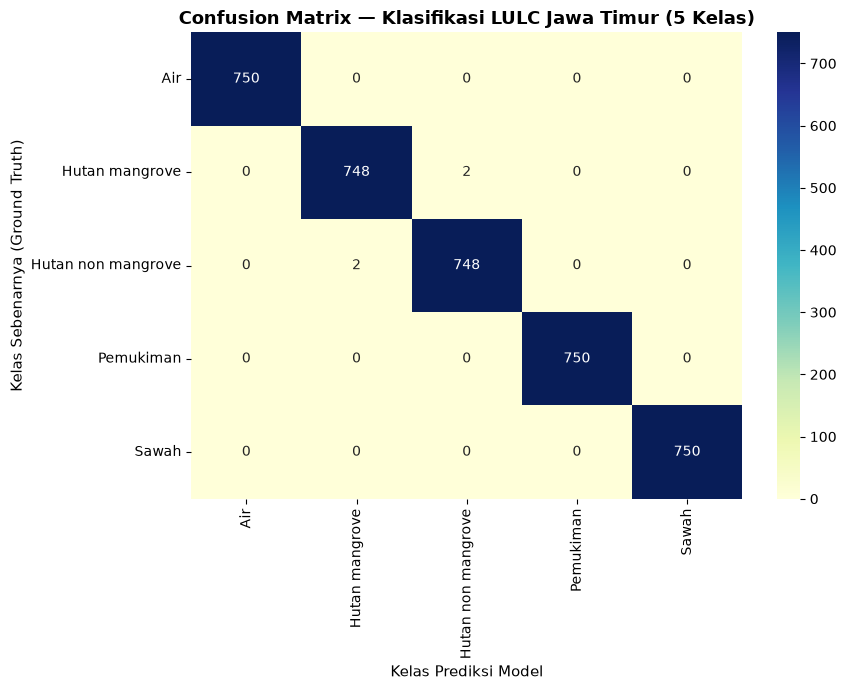

In [4]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prediksi pada Data Uji
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("==================================================")
print("             RINGKASAN METRIK EVALUASI             ")
print("==================================================")
print(f"Overall Accuracy : {accuracy * 100:.2f}%")
print(f"Cohen's Kappa    : {kappa:.4f}\n")

print("=== CLASSIFICATION REPORT DETIL PER KELAS ===")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix Heatmap
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Klasifikasi LULC Jawa Timur (5 Kelas)", fontsize=13, fontweight='bold')
plt.xlabel("Kelas Prediksi Model", fontsize=11)
plt.ylabel("Kelas Sebenarnya (Ground Truth)", fontsize=11)
plt.tight_layout()
plt.show()


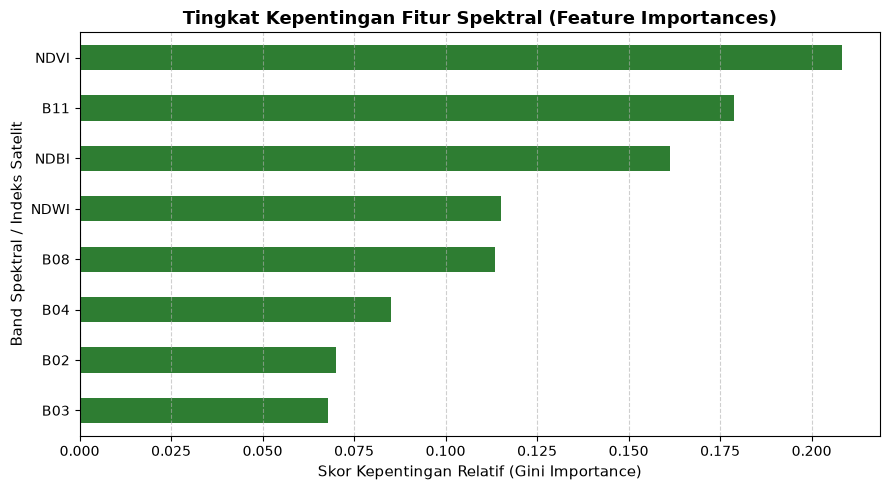

In [5]:
# Mengambil Nilai Relative Importance dari Random Forest Model
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="#2e7d32")
plt.title("Tingkat Kepentingan Fitur Spektral (Feature Importances)", fontsize=13, fontweight='bold')
plt.xlabel("Skor Kepentingan Relatif (Gini Importance)", fontsize=11)
plt.ylabel("Band Spektral / Indeks Satelit", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
